In [ ]:
'Pengolahan citra p2'

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


tipe data: <class 'numpy.ndarray'>
shape    : (700, 800, 3)
dtype   : uint8

artinya: 
Tinggi = 700 piksel
lebar = 800 piksel
channel = 3 piksel
total pixel:  560000


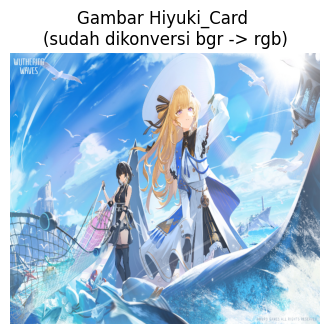

In [3]:
# Baca gambar dari file
#cv2.imread() mengembalikan array numpy !
img_bgr = cv2.imread('wallpaperflare.com_wallpaper13.jpg.jpg')

#resize agar tidak terlalu besar
img_bgr = cv2.resize(img_bgr, (800,700))

#cek tipe data : ternyata sudah array numpy!
print("tipe data:", type(img_bgr))
print("shape    :", img_bgr.shape)
print("dtype   :", img_bgr.dtype)

print()
print("artinya: ")
print(f"Tinggi = {img_bgr.shape[0]} piksel")
print(f"lebar = {img_bgr.shape[1]} piksel")
print(f"channel = {img_bgr.shape[2]} piksel")

#konversi bgr -> rgb untuk ditampilkan di matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("total pixel: ", img_rgb.shape[0] * img_rgb.shape[1])

plt.figure(figsize=(4,6))
plt.imshow(img_rgb)
plt.title('Gambar Hiyuki_Card \n(sudah dikonversi bgr -> rgb)')
plt.axis('off')
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[118 126 116 151 123 116 107 107]
 [112 125 110 123 123 125 106 107]
 [118 118 116 123 123 134 109 104]
 [113 114 116 117 111 114 142 110]
 [106 115 105 106 113 118 129 134]
 [111 105 103 107 110 101 125 151]
 [117 103 103 112 118 108 108 104]
 [117 104 102 114 126 123 116 111]]

CONTOH baca: f(180, 200) = 162
CONTOH baca: f(181, 201) = 163
total pixel: 560000
total Size Kb: 546
total Size MB: 0.53
------------------------------


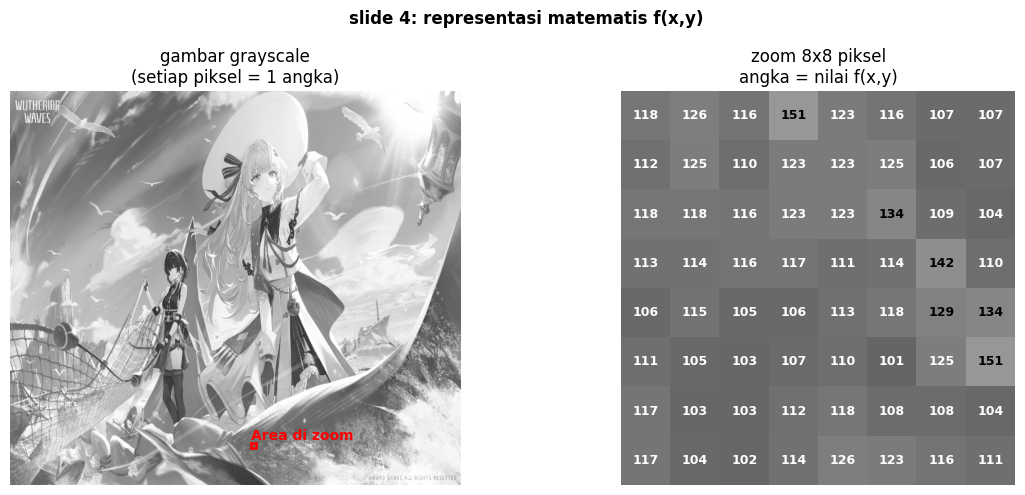

In [35]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#Ambil area kecil
area_kecil = img_gray[625:633, 428:436]

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
total_size_kb = img_rgb.nbytes / 1024
total_size_mb = total_size_kb / 1024

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
kb_gray = int(img_gray.nbytes / 1024)
mb_gray = img_gray.nbytes / (1024 * 1024)

print(f"CONTOH baca: f(180, 200) = {img_gray[200, 180]}")
print(f"CONTOH baca: f(181, 201) = {img_gray[201, 181]}")
print(f"total pixel: {img_gray.shape[0] * img_gray.shape[1]}")
print(f"total Size Kb: {kb_gray}")
print(f"total Size MB: {mb_gray:.2f}")
print("-" * 30)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')
rect=patches.Rectangle((428, 625), 8, 8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(428, 620, 'Area di zoom', color='red', fontsize=10, fontweight='bold')

axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center',
                 fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

Row 0: [68, 131, 178], [71, 141, 191], [69, 128, 177], [110, 162, 206], [82, 133, 180], [68, 129, 179], [61, 119, 169], [61, 118, 173]
Row 1: [66, 123, 176], [72, 140, 188], [68, 120, 173], [79, 134, 182], [76, 136, 183], [69, 142, 187], [59, 118, 167], [60, 119, 172]
Row 2: [68, 130, 183], [73, 129, 183], [68, 129, 174], [73, 137, 181], [75, 136, 181], [84, 148, 193], [71, 118, 166], [62, 114, 164]
Row 3: [64, 125, 179], [62, 128, 180], [67, 129, 174], [69, 130, 178], [65, 122, 175], [72, 124, 173], [108, 149, 194], [71, 120, 163]
Row 4: [65, 116, 165], [70, 126, 176], [66, 114, 163], [59, 118, 168], [64, 125, 179], [78, 127, 178], [96, 136, 176], [93, 146, 183]
Row 5: [66, 122, 169], [66, 114, 161], [64, 112, 159], [61, 119, 167], [63, 122, 174], [63, 109, 157], [91, 133, 174], [120, 158, 196]
Row 6: [66, 131, 178], [64, 112, 159], [66, 111, 160], [66, 124, 170], [67, 132, 178], [6

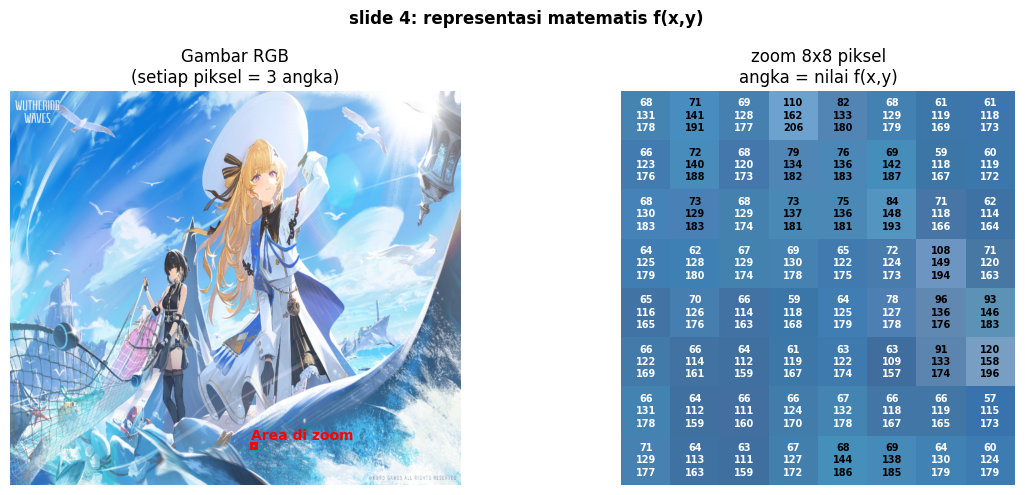

In [36]:
import matplotlib.patches as patches


#Ambil area kecil
area_kecil_rgb = img_rgb[625:633, 428:436]
total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
total_size_kb = int(img_rgb.nbytes / 1024)
total_size_mb = total_size_kb / 1024

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
for row_index, row in enumerate(area_kecil_rgb):
    row_str = []
    for pixel in row:
        row_str.append(f"[{pixel[0]}, {pixel[1]}, {pixel[2]}]")
    print(f"Row {row_index}: {', '.join(row_str)}")
print()
kb_rgb = int(img_rgb.nbytes / 1024)
mb_rgb = img_rgb.nbytes / (1024 * 1024)

print(f"CONTOH baca: f(210, 190) = {img_rgb[210, 190].tolist()}")
print(f"CONTOH baca: f(211, 191) = {img_rgb[211, 191].tolist()}")
print(f"total pixel: {img_rgb.shape[0] * img_rgb.shape[1]}")
print(f"total Size Kb: {kb_rgb}")
print(f"total Size MB: {mb_rgb:.2f}")
print("-" * 30)


fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')
rect=patches.Rectangle((428, 625), 8, 8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(428, 620, 'Area di zoom', color='red', fontsize=10, fontweight='bold')

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    r, g, b = area_kecil_rgb[i, j]
    teks_rgb = f"{r}\n{g}\n{b}"
    avg_nilai = np.mean([r, g, b])
    warna_teks = 'white' if avg_nilai < 128 else 'black'
    axes[1].text(j, i, teks_rgb, ha='center', va='center',
                 fontsize=7, color=warna_teks, fontweight='bold',
                 linespacing=1.3)
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()